In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import smarts_cerebellum.globals as gl

In [2]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'WM'

# obs means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')

# pred means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')
patients_lme = patients_lme.drop(columns = ['subj_id', 'random_intercept', 'Unnamed: 0']).drop_duplicates().reset_index(drop = True)
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')
controls_lme = controls_lme.drop(columns = ['subj_id', 'random_intercept', 'Unnamed: 0']).drop_duplicates().reset_index(drop = True)

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[0]
controls_lme['hemisphere'] = controls_lme.regionname.str[0]
patients_actual['hemisphere'] = patients_actual.regionname.str[0]
controls_actual['hemisphere'] = controls_actual.regionname.str[0]

# bilateral controls (take mean of both hemispheres)
controls_lme = controls_lme.groupby(['Week']).agg({'beta': 'mean', 'se': 'mean'}).reset_index()
controls_actual = controls_actual.groupby(['Week']).agg({'mean': 'mean'}).reset_index()

controls_lme = controls_lme.sort_values('Week')
controls_actual = controls_actual.sort_values('Week')

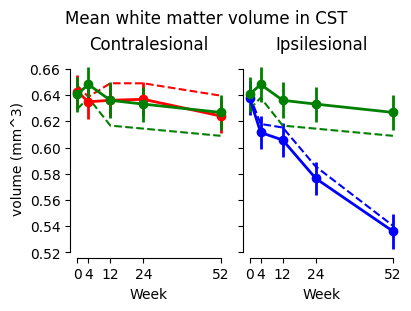

In [3]:
colours = ['green', 'r', 'blue']


fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

for i, H in enumerate(gl.Hem):

    ax = axs[i]

    patients_lme_h    = patients_lme[patients_lme.hemisphere == H].sort_values('Week')
    patients_actual_h = patients_actual[patients_actual.hemisphere == H].sort_values('Week')


    ax.errorbar(x=patients_lme_h['Week'], y=patients_lme_h['beta'], yerr = patients_lme_h['se'], fmt = '-o', color = colours[i+1], linewidth = 2, label = 'patients')
    ax.plot(patients_actual_h['Week'], patients_actual_h['mean'], color = colours[i+1], linestyle = '--')

    ax.errorbar(x=controls_lme['Week'], y=controls_lme['beta'], yerr = controls_lme['se'], fmt = '-o', color = 'green', linewidth = 2, label = 'controls')
    ax.plot(controls_actual['Week'], controls_actual['mean'], color = 'green', linestyle = '--',)

    ax.set_title("Contralesional")

for i in range(2):
    axs[i].set_xticks(gl.weeks)
    axs[i].set_xlabel("Week")
    axs[i].set_title(gl.side[i])

axs[0].set_ylabel('volume (mm^3)')

fig.suptitle('Mean white matter volume in CST')
sns.despine(trim = True)

fig.savefig('figure/lme_CST.pdf')

plt.show()